# Correlation Analysis — Food Delivery & Flipkart Mobile Phones

This notebook completes all four requested tasks using **Pandas**, **Seaborn**, **NumPy**, and **Matplotlib**.

### Tasks covered
1. Create 20 rows of random food-delivery data and calculate the `.corr()` matrix.
2. Plot the correlation matrix as an annotated Seaborn heatmap.
3. Use a diverging palette (`coolwarm`) and identify the strongest negative correlation.
4. Load a small sample based on a public Flipkart mobile dataset, compute correlations for at least four numeric columns, and create an annotated diverging heatmap.



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
sns.set_theme(style='whitegrid')

## Task 1 — Create 20 random food-delivery orders and calculate the correlation matrix

In [ ]:
rng = np.random.default_rng(42)
n = 20

delivery_distance = rng.uniform(1.0, 15.0, n)
delivery_time = 22 + 2.7 * delivery_distance + rng.normal(0, 2.2, n)
order_value = rng.uniform(200, 2000, n)
tip_amount = 0.04 * order_value + rng.normal(0, 12, n)
rating = 4.9 - 0.055 * delivery_time + rng.normal(0, 0.15, n)
rating = np.clip(rating, 1, 5)

food_df = pd.DataFrame({
    'delivery_time': np.round(delivery_time, 1),
    'order_value': np.round(order_value, 2),
    'tip_amount': np.round(np.maximum(tip_amount, 0), 2),
    'rating': np.round(rating, 2),
    'delivery_distance': np.round(delivery_distance, 2),
})

print('Food Delivery Data (20 rows):')
display(food_df)

food_corr = food_df.corr(numeric_only=True)
print('\nCorrelation Matrix:')
display(food_corr.round(2))

Food Delivery Data (20 rows):


,delivery_time,order_value,tip_amount,rating,delivery_distance
0,53.5,986.87,29.08,2.05,11.84
1,39.8,1698.82,79.57,2.67,7.14
2,59.8,1460.48,38.22,1.68,13.02
3,50.7,762.26,26.47,2.01,10.76
4,27.3,1698.07,69.88,3.34,2.32
5,60.8,1648.58,72.98,1.50,14.66
6,54.6,897.46,44.43,1.72,11.66
7,55.2,718.99,38.28,1.94,12.00
8,30.5,1428.49,52.95,3.15,2.79
9,42.7,451.55,12.51,2.55,7.31



Correlation Matrix:


,delivery_time,order_value,tip_amount,rating,delivery_distance
delivery_time,1.00,-0.36,-0.46,-0.98,0.99
order_value,-0.36,1.00,0.90,0.38,-0.33
tip_amount,-0.46,0.90,1.00,0.47,-0.44
rating,-0.98,0.38,0.47,1.00,-0.98
delivery_distance,0.99,-0.33,-0.44,-0.98,1.00


## Task 2 — Seaborn annotated heatmap

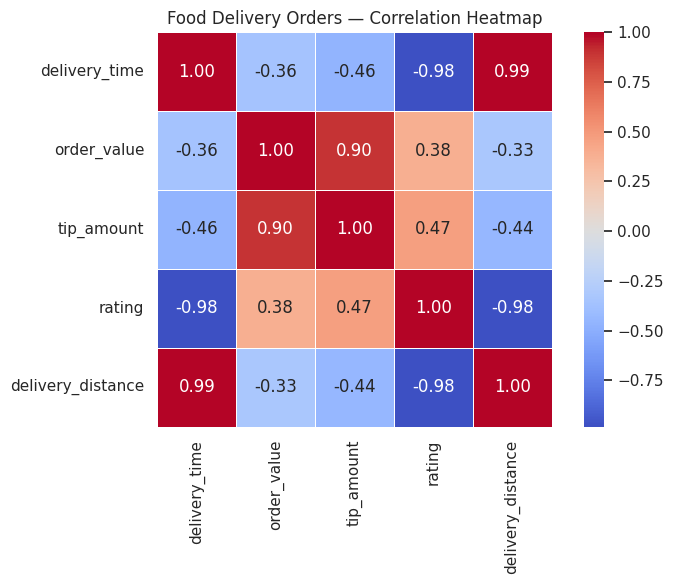

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    food_corr,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cmap='coolwarm',
    center=0
)
plt.title('Food Delivery Orders — Correlation Heatmap')
plt.tight_layout()
plt.show()

## Task 3 — Diverging palette and strongest negative correlation

In [ ]:
# Extract unique feature pairs so we don't compare each pair twice.
pairs = food_corr.where(np.triu(np.ones(food_corr.shape), 1).astype(bool)).stack()
strongest_negative_pair = pairs.idxmin()
strongest_negative_value = pairs.min()

print(f'Strongest negative correlation: {strongest_negative_pair[0]} vs {strongest_negative_pair[1]}')
print(f'Correlation coefficient: {strongest_negative_value:.2f}')

Strongest negative correlation: delivery_time vs rating
Correlation coefficient: -0.98


### Explanation

In this generated dataset, **delivery_time** and **rating** have the strongest negative correlation, with **r = -0.98**.

This means that, within these 20 simulated orders, higher values of one feature tend to be associated with lower values of the other. Because the data are randomly generated for practice, this relationship is illustrative rather than a real-world business conclusion.

## Task 4 — Flipkart mobile phone sample: correlation matrix and heatmap

In [ ]:
# The accompanying CSV is a small sample taken from the public Flipkart mobile dataset.
# It contains four numeric analysis columns: RAM_GB, Storage_GB, Rating, Selling Price.
phone_df = pd.read_csv('flipkart_mobile_sample.csv')

print('Flipkart mobile sample:')
display(phone_df.head(10))

phone_numeric = phone_df[['RAM_GB', 'Storage_GB', 'Rating', 'Selling Price']]
phone_corr = phone_numeric.corr()

print('Numeric correlation matrix:')
display(phone_corr.round(2))

Flipkart mobile sample:


,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,RAM_GB,Storage_GB
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990.0,4.0,64.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990.0,4.0,64.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990.0,6.0,128.0
3,OPPO,A12,Black,3 GB,32 GB,4.4,9490,10990.0,3.0,32.0
4,OPPO,A12,Flowing Silver,4 GB,64 GB,4.4,10490,11990.0,4.0,64.0
5,OPPO,A53s 5G,Crystal Blue,6 GB,128 GB,4.3,15990,16990.0,6.0,128.0
6,OPPO,A53s 5G,Crystal Blue,8 GB,128 GB,4.3,17990,18990.0,8.0,128.0
7,OPPO,A33,Moonlight Black,3 GB,32 GB,4.3,10490,12990.0,3.0,32.0
8,OPPO,A31,Lake Green,4 GB,64 GB,4.3,11960,12990.0,4.0,64.0
9,OPPO,A31,Mystery Black,6 GB,128 GB,4.3,13799,NaN,6.0,128.0


Numeric correlation matrix:


,RAM_GB,Storage_GB,Rating,Selling Price
RAM_GB,1.00,0.83,0.16,0.75
Storage_GB,0.83,1.00,0.18,0.78
Rating,0.16,0.18,1.00,0.14
Selling Price,0.75,0.78,0.14,1.00


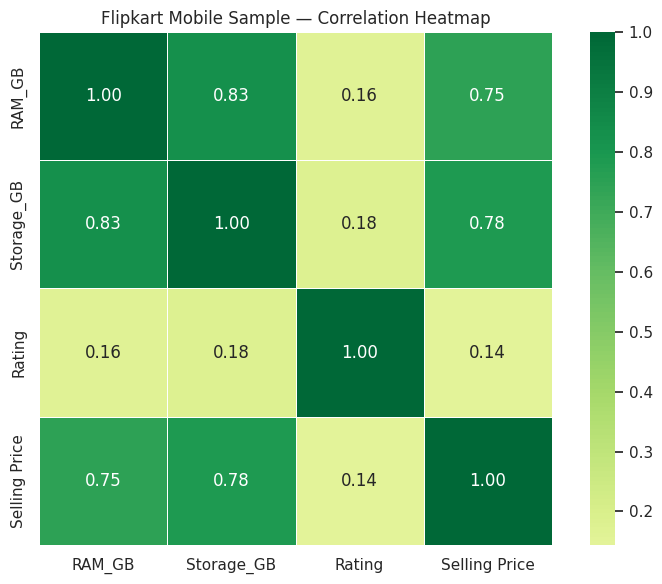

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    phone_corr,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cmap='RdYlGn',
    center=0
)
plt.title('Flipkart Mobile Sample — Correlation Heatmap')
plt.tight_layout()
plt.show()

### Final takeaway

The notebook demonstrates how `.corr()` quantifies linear relationships and how Seaborn heatmaps make positive and negative correlations easy to compare. The diverging palettes place correlations near zero around the midpoint and visually separate positive from negative relationships.